# 03 - Backpropagation and Autograd Intuition

---

## Learning Objectives

By the end of this notebook, you will be able to:

- Apply the **chain rule** to compute gradients through a computational graph
- Understand **backpropagation** as repeated application of the chain rule
- Implement a step-by-step backprop example on a tiny 2-layer network in NumPy
- Visualize **gradient flow** through a network
- Understand how PyTorch **autograd** automates gradient computation

## Prerequisites

- Completed [01 - What is a Neural Network?](01_What_is_a_Neural_Network.ipynb)
- Completed [02 - Forward Propagation and Activations](02_Forward_Propagation_and_Activations.ipynb)
- Basic calculus: derivatives, chain rule, partial derivatives

## Table of Contents

1. [Why We Need Gradients](#1-why-we-need-gradients)
2. [The Chain Rule](#2-the-chain-rule)
3. [Computational Graph Intuition](#3-computational-graph-intuition)
4. [Step-by-Step Backpropagation Example](#4-step-by-step-backpropagation-example)
5. [Gradient Flow Visualization](#5-gradient-flow-visualization)
6. [Transition to PyTorch Autograd](#6-transition-to-pytorch-autograd)
7. [Exercise: Hand-Compute and Verify Gradients](#7-exercise-hand-compute-and-verify-gradients)
8. [Common Mistakes & Debugging Tips](#8-common-mistakes--debugging-tips)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

---
## 1. Why We Need Gradients

Training a neural network means finding weights $\mathbf{W}$ and biases $\mathbf{b}$ that minimize a **loss function** $L$.

**Gradient descent** is the optimization algorithm:

$$w \leftarrow w - \eta \frac{\partial L}{\partial w}$$

where $\eta$ is the learning rate.

To update every weight in the network, we need the **gradient** $\frac{\partial L}{\partial w}$ for each weight. Backpropagation is the efficient algorithm for computing all these gradients in one backward pass through the network.

---
## 2. The Chain Rule

Backpropagation is just the **chain rule** from calculus applied systematically.

If $L$ depends on $w$ through intermediate variables:

$$w \xrightarrow{\text{linear}} z \xrightarrow{\text{activation}} a \xrightarrow{\text{loss}} L$$

Then:

$$\boxed{\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w}}$$

Each factor has a clear meaning:
- $\frac{\partial L}{\partial a}$: How much the loss changes when the activation changes
- $\frac{\partial a}{\partial z}$: How much the activation changes when the pre-activation changes (= derivative of the activation function)
- $\frac{\partial z}{\partial w}$: How much the pre-activation changes when the weight changes (= the input $x$, since $z = wx + b$)

---
## 3. Computational Graph Intuition

A **computational graph** breaks a complex computation into elementary operations, each represented as a node. The forward pass flows left to right; the backward pass flows right to left.

**Example:** Single neuron with MSE loss

```
Forward pass (left to right):

  x ---\
        (*w)--> [+b] --> z --> [sigmoid] --> a --> [MSE loss] --> L
  w ---/                                           ^
                                                   |
                                                y_true

Backward pass (right to left):

  dL/dx <--\
             dL/dz <-- dL/da <-- dL/dL = 1
  dL/dw <--/
```

At each node in the backward pass, we multiply the incoming gradient by the **local gradient** (the derivative of that node's operation).

Let us visualize this with matplotlib.

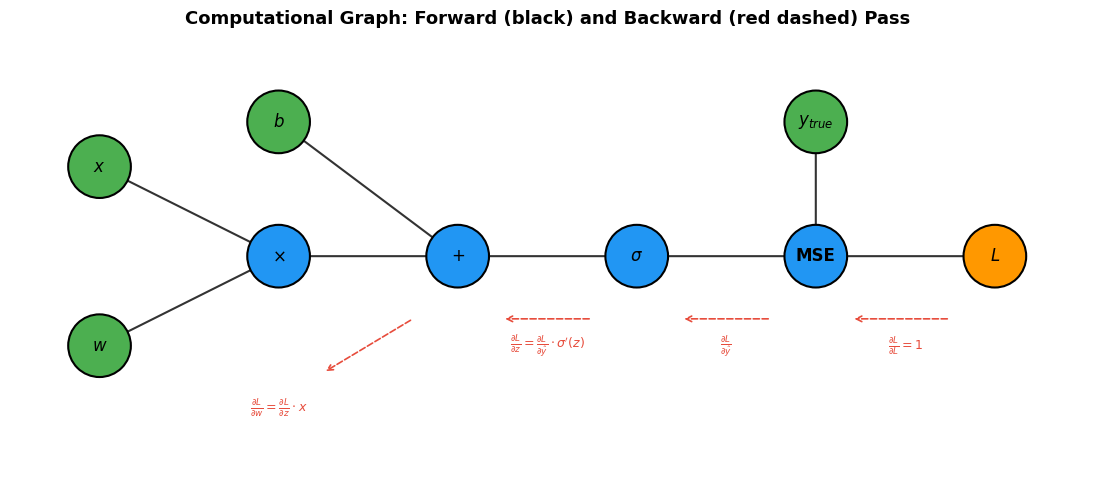

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Node positions
nodes = {
    'x':      (0.5, 3.0),
    'w':      (0.5, 1.0),
    'mult':   (2.5, 2.0),
    'b':      (2.5, 3.5),
    'add':    (4.5, 2.0),
    'sigma':  (6.5, 2.0),
    'y':      (8.5, 3.5),
    'loss':   (8.5, 2.0),
    'L':      (10.5, 2.0),
}

# Draw edges (arrows)
edges = [
    ('x', 'mult'), ('w', 'mult'),
    ('mult', 'add'), ('b', 'add'),
    ('add', 'sigma'),
    ('sigma', 'loss'), ('y', 'loss'),
    ('loss', 'L'),
]

for (src, dst) in edges:
    x1, y1 = nodes[src]
    x2, y2 = nodes[dst]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

# Draw nodes
node_labels = {
    'x': '$x$', 'w': '$w$',
    'mult': '$\\times$', 'b': '$b$',
    'add': '$+$', 'sigma': '$\\sigma$',
    'y': '$y_{true}$', 'loss': 'MSE',
    'L': '$L$',
}

input_nodes = {'x', 'w', 'b', 'y'}
for name, (x, y) in nodes.items():
    if name in input_nodes:
        color = '#4CAF50'
        radius = 0.35
    elif name == 'L':
        color = '#FF9800'
        radius = 0.35
    else:
        color = '#2196F3'
        radius = 0.35
    circle = plt.Circle((x, y), radius, color=color, ec='black', lw=1.5, zorder=4)
    ax.add_patch(circle)
    ax.text(x, y, node_labels[name], ha='center', va='center',
            fontsize=12, fontweight='bold', zorder=5)

# Add backward pass annotations
backward_labels = [
    (9.5, 1.0, '$\\frac{\\partial L}{\\partial L} = 1$', '#e74c3c'),
    (7.5, 1.0, '$\\frac{\\partial L}{\\partial \\hat{y}}$', '#e74c3c'),
    (5.5, 1.0, '$\\frac{\\partial L}{\\partial z} = \\frac{\\partial L}{\\partial \\hat{y}} \\cdot \\sigma\'(z)$', '#e74c3c'),
    (2.5, 0.3, '$\\frac{\\partial L}{\\partial w} = \\frac{\\partial L}{\\partial z} \\cdot x$', '#e74c3c'),
]
for (x, y, label, color) in backward_labels:
    ax.text(x, y, label, ha='center', va='center', fontsize=9, color=color)

# Draw backward arrows (dashed red)
back_edges = [(10.0, 1.3, 8.9, 1.3), (8.0, 1.3, 7.0, 1.3),
              (6.0, 1.3, 5.0, 1.3), (4.0, 1.3, 3.0, 0.7)]
for (x1, y1, x2, y2) in back_edges:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, linestyle='--'))

ax.set_xlim(-0.5, 11.5)
ax.set_ylim(-0.5, 4.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Computational Graph: Forward (black) and Backward (red dashed) Pass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Step-by-Step Backpropagation Example

Let us work through a complete example on a tiny 2-layer network.

**Architecture:** 2 inputs $\rightarrow$ 2 hidden (sigmoid) $\rightarrow$ 1 output (sigmoid)

**Loss:** MSE = $\frac{1}{2}(y - \hat{y})^2$ (using $\frac{1}{2}$ for cleaner derivatives)

### Step 1: Forward Pass

In [3]:
# Helper functions
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(z):
    """Derivative of sigmoid w.r.t. z."""
    s = sigmoid(z)
    return s * (1 - s)


# ============================================================
# Network setup: 2 -> 2 -> 1
# ============================================================
np.random.seed(42)

# Input and target
x = np.array([0.5, 0.8])      # shape (2,)
y_true = np.array([1.0])      # target

# Layer 1 weights and biases
W1 = np.array([[0.15, 0.20],
               [0.25, 0.30]])  # shape (2, 2)
b1 = np.array([0.35, 0.35])   # shape (2,)

# Layer 2 weights and biases
W2 = np.array([[0.40, 0.45]]) # shape (1, 2)
b2 = np.array([0.60])         # shape (1,)

# ============================================================
# FORWARD PASS
# ============================================================
print("=" * 60)
print("FORWARD PASS")
print("=" * 60)

# Layer 1
z1 = W1 @ x + b1
a1 = sigmoid(z1)
print(f"\nLayer 1:")
print(f"  z1 = W1 @ x + b1 = {z1}")
print(f"  a1 = sigmoid(z1) = {a1}")

# Layer 2
z2 = W2 @ a1 + b2
a2 = sigmoid(z2)
y_hat = a2
print(f"\nLayer 2:")
print(f"  z2 = W2 @ a1 + b2 = {z2}")
print(f"  a2 = sigmoid(z2) = {y_hat}")

# Loss (MSE with 1/2 factor)
loss = 0.5 * (y_true - y_hat) ** 2
print(f"\nPrediction: {y_hat[0]:.6f}")
print(f"Target:     {y_true[0]:.6f}")
print(f"Loss:       {loss[0]:.6f}")

FORWARD PASS

Layer 1:
  z1 = W1 @ x + b1 = [0.585 0.715]
  a1 = sigmoid(z1) = [0.64221709 0.67150503]

Layer 2:
  z2 = W2 @ a1 + b2 = [1.1590641]
  a2 = sigmoid(z2) = [0.76116262]

Prediction: 0.761163
Target:     1.000000
Loss:       0.028522


### Step 2: Backward Pass (Backpropagation)

Now we compute gradients layer by layer, from the loss back to the inputs.

**Key derivative formulas:**

1. Loss gradient: $\frac{\partial L}{\partial \hat{y}} = -(y - \hat{y})$

2. Output layer:
   - $\frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial \hat{y}} \cdot \sigma'(z_2)$
   - $\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial z_2} \cdot a_1^T$
   - $\frac{\partial L}{\partial b_2} = \frac{\partial L}{\partial z_2}$

3. Hidden layer:
   - $\frac{\partial L}{\partial a_1} = W_2^T \cdot \frac{\partial L}{\partial z_2}$
   - $\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial a_1} \odot \sigma'(z_1)$
   - $\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_1} \cdot x^T$
   - $\frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial z_1}$

In [4]:
# ============================================================
# BACKWARD PASS
# ============================================================
print("=" * 60)
print("BACKWARD PASS")
print("=" * 60)

# Step 1: Gradient of loss w.r.t. prediction
dL_da2 = -(y_true - y_hat)  # dL/d(y_hat) = -(y - y_hat)
print(f"\nStep 1: dL/da2 = -(y - y_hat) = {dL_da2}")

# Step 2: Gradient through output activation
da2_dz2 = sigmoid_derivative(z2)  # sigma'(z2)
dL_dz2 = dL_da2 * da2_dz2        # element-wise
print(f"\nStep 2: da2/dz2 = sigma'(z2)   = {da2_dz2}")
print(f"         dL/dz2 = dL/da2 * da2/dz2 = {dL_dz2}")

# Step 3: Gradients for W2 and b2
dL_dW2 = dL_dz2.reshape(-1, 1) @ a1.reshape(1, -1)  # outer product
dL_db2 = dL_dz2
print(f"\nStep 3: dL/dW2 = dL/dz2 * a1^T = {dL_dW2}")
print(f"         dL/db2 = dL/dz2         = {dL_db2}")

# Step 4: Gradient flowing back to hidden layer
dL_da1 = W2.T @ dL_dz2  # shape (2,)
print(f"\nStep 4: dL/da1 = W2^T @ dL/dz2 = {dL_da1.flatten()}")

# Step 5: Gradient through hidden activation
da1_dz1 = sigmoid_derivative(z1)
dL_dz1 = dL_da1.flatten() * da1_dz1  # element-wise (Hadamard product)
print(f"\nStep 5: da1/dz1 = sigma'(z1)   = {da1_dz1}")
print(f"         dL/dz1 = dL/da1 * da1/dz1 = {dL_dz1}")

# Step 6: Gradients for W1 and b1
dL_dW1 = dL_dz1.reshape(-1, 1) @ x.reshape(1, -1)  # outer product
dL_db1 = dL_dz1
print(f"\nStep 6: dL/dW1 = dL/dz1 * x^T =")
print(f"         {dL_dW1}")
print(f"         dL/db1 = dL/dz1 = {dL_db1}")

BACKWARD PASS

Step 1: dL/da2 = -(y - y_hat) = [-0.23883738]

Step 2: da2/dz2 = sigma'(z2)   = [0.18179409]
         dL/dz2 = dL/da2 * da2/dz2 = [-0.04341922]

Step 3: dL/dW2 = dL/dz2 * a1^T = [[-0.02788457 -0.02915623]]
         dL/db2 = dL/dz2         = [-0.04341922]

Step 4: dL/da1 = W2^T @ dL/dz2 = [-0.01736769 -0.01953865]

Step 5: da1/dz1 = sigma'(z1)   = [0.2297743  0.22058602]
         dL/dz1 = dL/da1 * da1/dz1 = [-0.00399065 -0.00430995]

Step 6: dL/dW1 = dL/dz1 * x^T =
         [[-0.00199532 -0.00319252]
 [-0.00215498 -0.00344796]]
         dL/db1 = dL/dz1 = [-0.00399065 -0.00430995]


In [5]:
# ============================================================
# VERIFY with numerical gradients (finite differences)
# ============================================================
print("=" * 60)
print("VERIFICATION: Numerical Gradients (Finite Differences)")
print("=" * 60)

def compute_loss(x, y_true, W1, b1, W2, b2):
    """Compute forward pass and return loss."""
    z1 = W1 @ x + b1
    a1 = sigmoid(z1)
    z2 = W2 @ a1 + b2
    a2 = sigmoid(z2)
    return 0.5 * (y_true - a2) ** 2


def numerical_gradient(param, x, y_true, W1, b1, W2, b2, param_name, eps=1e-5):
    """Compute gradient numerically using central differences."""
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        old_val = param[idx]
        
        param[idx] = old_val + eps
        loss_plus = compute_loss(x, y_true, W1, b1, W2, b2)
        
        param[idx] = old_val - eps
        loss_minus = compute_loss(x, y_true, W1, b1, W2, b2)
        
        grad[idx] = (loss_plus - loss_minus) / (2 * eps)
        param[idx] = old_val
        it.iternext()
    return grad


# Make copies to avoid mutation
W1_copy = W1.copy()
W2_copy = W2.copy()
b1_copy = b1.copy()
b2_copy = b2.copy()

num_dW1 = numerical_gradient(W1_copy, x, y_true, W1_copy, b1_copy, W2_copy, b2_copy, 'W1')
num_dW2 = numerical_gradient(W2_copy, x, y_true, W1_copy, b1_copy, W2_copy, b2_copy, 'W2')
num_db1 = numerical_gradient(b1_copy, x, y_true, W1_copy, b1_copy, W2_copy, b2_copy, 'b1')
num_db2 = numerical_gradient(b2_copy, x, y_true, W1_copy, b1_copy, W2_copy, b2_copy, 'b2')

print(f"\ndL/dW2:  analytic={dL_dW2.flatten()},  numerical={num_dW2.flatten()}")
print(f"  Match: {np.allclose(dL_dW2, num_dW2, atol=1e-6)}")

print(f"\ndL/db2:  analytic={dL_db2},  numerical={num_db2}")
print(f"  Match: {np.allclose(dL_db2, num_db2, atol=1e-6)}")

print(f"\ndL/dW1:  analytic=\n{dL_dW1}")
print(f"         numerical=\n{num_dW1}")
print(f"  Match: {np.allclose(dL_dW1, num_dW1, atol=1e-6)}")

print(f"\ndL/db1:  analytic={dL_db1},  numerical={num_db1}")
print(f"  Match: {np.allclose(dL_db1, num_db1, atol=1e-6)}")

VERIFICATION: Numerical Gradients (Finite Differences)

dL/dW2:  analytic=[-0.02788457 -0.02915623],  numerical=[-0.02788457 -0.02915623]
  Match: True

dL/db2:  analytic=[-0.04341922],  numerical=[-0.04341922]
  Match: True

dL/dW1:  analytic=
[[-0.00199532 -0.00319252]
 [-0.00215498 -0.00344796]]
         numerical=
[[-0.00199532 -0.00319252]
 [-0.00215498 -0.00344796]]
  Match: True

dL/db1:  analytic=[-0.00399065 -0.00430995],  numerical=[-0.00399065 -0.00430995]
  Match: True


C:\Users\shrip\AppData\Local\Temp\ipykernel_53236\1298161878.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[idx] = (loss_plus - loss_minus) / (2 * eps)


If all matches are `True`, our backprop implementation is correct.

In [ ]:
# ============================================================
# APPLY GRADIENT DESCENT UPDATE and observe loss decrease
# ============================================================
learning_rate = 0.5

# Store loss history
losses = []

# Reset weights
W1_train = np.array([[0.15, 0.20], [0.25, 0.30]])
b1_train = np.array([0.35, 0.35])
W2_train = np.array([[0.40, 0.45]])
b2_train = np.array([0.60])

for step in range(100):
    # Forward
    z1_t = W1_train @ x + b1_train
    a1_t = sigmoid(z1_t)
    z2_t = W2_train @ a1_t + b2_train
    a2_t = sigmoid(z2_t)
    loss_t = 0.5 * (y_true - a2_t) ** 2
    losses.append(loss_t[0])
    
    # Backward
    dL_da2_t = -(y_true - a2_t)
    dL_dz2_t = dL_da2_t * sigmoid_derivative(z2_t)
    dL_dW2_t = dL_dz2_t.reshape(-1, 1) @ a1_t.reshape(1, -1)
    dL_db2_t = dL_dz2_t
    dL_da1_t = (W2_train.T @ dL_dz2_t).flatten()
    dL_dz1_t = dL_da1_t * sigmoid_derivative(z1_t)
    dL_dW1_t = dL_dz1_t.reshape(-1, 1) @ x.reshape(1, -1)
    dL_db1_t = dL_dz1_t
    
    # Update
    W2_train -= learning_rate * dL_dW2_t
    b2_train -= learning_rate * dL_db2_t
    W1_train -= learning_rate * dL_dW1_t
    b1_train -= learning_rate * dL_db1_t

print(f"Initial loss: {losses[0]:.6f}")
print(f"Final loss:   {losses[-1]:.6f}")
print(f"Final prediction: {a2_t[0]:.6f} (target: {y_true[0]})")

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss Decreasing with Gradient Descent', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Gradient Flow Visualization

Gradient flow refers to how gradients propagate backward through the network. Understanding this is key to diagnosing training problems.

- **Vanishing gradients:** Gradients shrink as they flow back, making early layers learn very slowly.
- **Exploding gradients:** Gradients grow, causing unstable training.

Let us visualize gradient magnitudes at each layer in a deeper network.

In [ ]:
def build_and_backprop_deep(n_layers, n_neurons, activation='sigmoid'):
    """
    Build a deep network and compute gradient magnitudes at each layer.
    
    Returns gradient norms at each layer to visualize gradient flow.
    """
    np.random.seed(42)
    
    if activation == 'sigmoid':
        act_fn = sigmoid
        act_deriv = sigmoid_derivative
    elif activation == 'relu':
        act_fn = lambda z: np.maximum(0, z)
        act_deriv = lambda z: (z > 0).astype(float)
    
    # Initialize weights and perform forward pass
    weights = []
    biases = []
    zs = []  # pre-activations
    activations_list = []  # post-activations
    
    # Input
    a = np.random.randn(n_neurons)
    activations_list.append(a)
    
    # Build layers
    for i in range(n_layers):
        W = np.random.randn(n_neurons, n_neurons) * 0.5
        b = np.zeros(n_neurons)
        weights.append(W)
        biases.append(b)
        
        z = W @ a + b
        a = act_fn(z)
        zs.append(z)
        activations_list.append(a)
    
    # Backward pass - start with random "loss gradient"
    grad = np.ones(n_neurons)  # dL/da for output
    grad_norms = [np.linalg.norm(grad)]
    
    for i in range(n_layers - 1, -1, -1):
        grad = grad * act_deriv(zs[i])  # through activation
        grad = weights[i].T @ grad      # through linear
        grad_norms.append(np.linalg.norm(grad))
    
    grad_norms.reverse()
    return grad_norms


# Compare gradient flow: sigmoid vs ReLU
n_layers = 10
n_neurons = 8

norms_sigmoid = build_and_backprop_deep(n_layers, n_neurons, 'sigmoid')
norms_relu = build_and_backprop_deep(n_layers, n_neurons, 'relu')

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
layers = list(range(len(norms_sigmoid)))
ax.plot(layers, norms_sigmoid, 'r-o', label='Sigmoid', linewidth=2, markersize=6)
ax.plot(layers, norms_relu, 'b-s', label='ReLU', linewidth=2, markersize=6)
ax.set_xlabel('Layer (0 = input, rightmost = output)', fontsize=12)
ax.set_ylabel('Gradient Norm', fontsize=12)
ax.set_title('Gradient Flow: Sigmoid vs ReLU (10-layer network)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Sigmoid: gradient norm at input layer = {norms_sigmoid[0]:.6e}")
print(f"ReLU:    gradient norm at input layer = {norms_relu[0]:.6e}")
print("\nNotice how sigmoid gradients vanish exponentially, while ReLU preserves gradient magnitude.")

---
## 6. Transition to PyTorch Autograd

Computing gradients by hand is educational, but impractical for real networks with millions of parameters. **PyTorch autograd** does this automatically.

Here is the same 2-layer network example in PyTorch, showing that autograd produces identical gradients.

In [ ]:
import torch

# Same values as our NumPy example
x_t = torch.tensor([0.5, 0.8], dtype=torch.float32)
y_t = torch.tensor([1.0], dtype=torch.float32)

W1_t = torch.tensor([[0.15, 0.20], [0.25, 0.30]], dtype=torch.float32, requires_grad=True)
b1_t = torch.tensor([0.35, 0.35], dtype=torch.float32, requires_grad=True)
W2_t = torch.tensor([[0.40, 0.45]], dtype=torch.float32, requires_grad=True)
b2_t = torch.tensor([0.60], dtype=torch.float32, requires_grad=True)

# Forward pass (PyTorch builds computational graph automatically)
z1_t = W1_t @ x_t + b1_t
a1_t = torch.sigmoid(z1_t)
z2_t = W2_t @ a1_t + b2_t
a2_t = torch.sigmoid(z2_t)
loss_t = 0.5 * (y_t - a2_t) ** 2

# Backward pass (one line!)
loss_t.backward()

# Compare with our manual gradients
print("PyTorch autograd vs our manual backprop:")
print(f"\ndL/dW2:")
print(f"  Manual:   {dL_dW2}")
print(f"  Autograd: {W2_t.grad.numpy()}")
print(f"  Match:    {np.allclose(dL_dW2, W2_t.grad.numpy(), atol=1e-6)}")

print(f"\ndL/dW1:")
print(f"  Manual:   {dL_dW1}")
print(f"  Autograd: {W1_t.grad.numpy()}")
print(f"  Match:    {np.allclose(dL_dW1, W1_t.grad.numpy(), atol=1e-6)}")

print(f"\ndL/db2: Manual={dL_db2}, Autograd={b2_t.grad.numpy()}")
print(f"dL/db1: Manual={dL_db1}, Autograd={b1_t.grad.numpy()}")

print("\n--- Key takeaway ---")
print("PyTorch computes the exact same gradients, but automatically!")
print("You just call .backward() and read .grad from each parameter.")

---
## 7. Exercise: Hand-Compute and Verify Gradients

**Task:** Given the simple computation below, compute the gradient $\frac{\partial L}{\partial w}$ by hand, then verify with code.

**Setup:**
- $x = 2.0$
- $w = 3.0$
- $b = 1.0$
- $z = w \cdot x + b = 7.0$
- $a = \sigma(z) = \sigma(7.0)$
- $y_{true} = 1.0$
- $L = (y_{true} - a)^2$

**Compute by hand:**
1. What is $\frac{\partial L}{\partial a}$?
2. What is $\frac{\partial a}{\partial z}$?
3. What is $\frac{\partial z}{\partial w}$?
4. Apply the chain rule: $\frac{\partial L}{\partial w} = ?$

```python
# Verify your hand computation here
x_ex = 2.0
w_ex = 3.0
b_ex = 1.0
y_true_ex = 1.0

# TODO: forward pass
# TODO: compute dL/dw analytically
# TODO: verify with numerical gradient
```

In [ ]:
# Try the exercise yourself before scrolling down!











### Solution

In [ ]:
# ----- Solution -----

x_ex = 2.0
w_ex = 3.0
b_ex = 1.0
y_true_ex = 1.0

# Forward pass
z_ex = w_ex * x_ex + b_ex
a_ex = sigmoid(z_ex)
L_ex = (y_true_ex - a_ex) ** 2

print(f"Forward pass:")
print(f"  z = {z_ex}")
print(f"  a = sigmoid({z_ex}) = {a_ex:.8f}")
print(f"  L = (1 - {a_ex:.8f})^2 = {L_ex:.10f}")

# Backward pass (by hand, using chain rule)
# 1. dL/da = -2(y_true - a) = -2(1 - a)
dL_da_ex = -2 * (y_true_ex - a_ex)
print(f"\nBackward pass:")
print(f"  dL/da = -2(y - a) = {dL_da_ex:.8f}")

# 2. da/dz = sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z))
da_dz_ex = a_ex * (1 - a_ex)
print(f"  da/dz = sigma'(z) = {da_dz_ex:.8f}")

# 3. dz/dw = x
dz_dw_ex = x_ex
print(f"  dz/dw = x = {dz_dw_ex}")

# 4. Chain rule: dL/dw = dL/da * da/dz * dz/dw
dL_dw_ex = dL_da_ex * da_dz_ex * dz_dw_ex
print(f"\n  dL/dw = dL/da * da/dz * dz/dw = {dL_dw_ex:.10f}")

# Numerical verification
eps = 1e-5
z_plus = (w_ex + eps) * x_ex + b_ex
z_minus = (w_ex - eps) * x_ex + b_ex
L_plus = (y_true_ex - sigmoid(z_plus)) ** 2
L_minus = (y_true_ex - sigmoid(z_minus)) ** 2
dL_dw_numerical = (L_plus - L_minus) / (2 * eps)

print(f"\n  Numerical dL/dw = {dL_dw_numerical:.10f}")
print(f"  Match: {np.isclose(dL_dw_ex, dL_dw_numerical, atol=1e-6)}")

# Also verify with PyTorch
w_torch = torch.tensor(3.0, requires_grad=True)
z_torch = w_torch * 2.0 + 1.0
a_torch = torch.sigmoid(z_torch)
L_torch = (1.0 - a_torch) ** 2
L_torch.backward()
print(f"  PyTorch dL/dw  = {w_torch.grad.item():.10f}")
print(f"  Match with PyTorch: {np.isclose(dL_dw_ex, w_torch.grad.item(), atol=1e-5)}")

---
## 8. Common Mistakes & Debugging Tips

**1. Gradient shapes do not match weight shapes**
- $\frac{\partial L}{\partial \mathbf{W}}$ must have the same shape as $\mathbf{W}$.
- Use the outer product formula: `dL_dW = dL_dz.reshape(-1,1) @ a_prev.reshape(1,-1)`.

**2. Confusing element-wise vs matrix multiplication in backward pass**
- Through activation: element-wise multiply ($\odot$): `dL_dz = dL_da * activation_deriv(z)`
- Through linear layer: matrix multiply: `dL_da_prev = W.T @ dL_dz`

**3. Not verifying gradients numerically**
- Always use finite-difference checking during development:
  $$\frac{\partial L}{\partial w} \approx \frac{L(w + \epsilon) - L(w - \epsilon)}{2\epsilon}$$
- If analytic and numerical gradients differ by more than $10^{-5}$, there is likely a bug.

**4. Forgetting to zero gradients in PyTorch**
- PyTorch *accumulates* gradients by default. Call `optimizer.zero_grad()` (or `param.grad.zero_()`) before each backward pass.

**5. In-place operations breaking autograd**
- Avoid in-place operations (e.g., `x += 1`) on tensors that require gradients.
- Use `x = x + 1` instead.

**6. Vanishing gradients in deep sigmoid/tanh networks**
- Maximum derivative of sigmoid is 0.25 (at $z=0$). After 10 layers: $0.25^{10} \approx 10^{-6}$.
- Solution: Use ReLU in hidden layers, batch normalization, or residual connections.

---

**Next notebook:** [04 - Loss Functions for Regression and Classification](04_Loss_Functions_Regression_Classification.ipynb) -- we learn about the loss functions that define what the network should optimize.